In [1]:

import os
import scipy.io
import h5py
import numpy as np
import sys
from scipy import signal as sig
from scipy import stats as stats
import math
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns
import logging

%matplotlib widget

scripts_path = '/home/apolo/Documents/github_projects/ripple_sync/scripts/hc_11_scripts/'
os.chdir(scripts_path)

import hc11_BaseFunctions as hc11_bf


scripts_path = '/home/apolo/Documents/github_projects/ripple_sync/scripts/hc_18_scripts/'
os.chdir(scripts_path)

import hc18_BaseFunctions as hc18_bf

sessions = ['Train-242-20140124','Train-261-20140617','Train-272-20141215','Train-292-20150501','Train-314-20160118']
animals = ['242','261','272','292','314']


In [2]:
event_name = 'SleepBaseline'
# event_name = 'PassiveForward'
    
output_dict = dict()
output_dict['rat'] = []
output_dict['session'] = []
output_dict['side'] = []
output_dict['shank_1'] = []
output_dict['shank_2'] = []
output_dict['phase_phase_coupling'] = []
output_dict['phase_phase_direction'] = []

srate = 1250.
ripple_threshold_level = 2
ripple_low_freq = 100
ripple_high_freq = 250
minimum_ripple_length = 0.03*srate
smooth_points = 0.001*srate

for animal_idx,session in enumerate(sessions):

    print(session)
    
    lfp,srate = hc18_bf.load_lfp_hc18_data(session)
    
    event_times, event_descriptions = hc18_bf.get_events(session, event_name)
    
    event_times = np.sort(np.array(event_times))
    event_start = np.nanmin(event_times)
    event_end = np.nanmax(event_times)

    shanks_electrodes,left_shanks,right_shanks = hc18_bf.get_shanks_info(session)

    filename = f'{scripts_path}/{session}_{event_name}_sleep_epochs.npy' 
    sleep_epochs = np.load(filename,allow_pickle=True).item()
    
    # lfp_index = np.round(np.arange(event_start*srate,event_end*srate)).astype(int)
    # lfp_epoch = lfp_index[0:int(60*60*srate)]
    lfp = np.double(lfp[:,sleep_epochs['theta_epochs']])
    lfp = sig.detrend(hc11_bf.eegfilt(lfp,srate,0.1,0))


    max_ripple_channels = []
    for channels in shanks_electrodes:
        ripple_lfp = lfp[channels,:].copy()
        ripple_filtered = sig.detrend(hc11_bf.eegfilt(ripple_lfp,srate,5,12))
        ripple_hilbert = hc11_bf.hilbert(ripple_filtered)
        ripple_amp = np.abs(ripple_hilbert)
    
        max_ripple_idx = np.argmax(np.nanmean(ripple_amp,1))
        max_ripple_channels.append(channels[max_ripple_idx])
    max_ripple_channels = np.array(max_ripple_channels)

    for shank_1 in np.arange(0,len(shanks_electrodes)-1):    
        
        print('Shank 1 = ' + str(shank_1))

        ripple_lfp_1 = lfp[max_ripple_channels[shank_1],:].copy()

        ripple_filtered_1 = sig.detrend(hc11_bf.eegfilt(ripple_lfp_1,srate,5,12))
        ripple_hilbert_1 = hc11_bf.hilbert(ripple_filtered_1)
        ripple_phase_1 = np.angle(ripple_hilbert_1)
        # ripple_amp_1 = np.abs(ripple_hilbert_1)

        for shank_2 in np.arange(shank_1+1,len(shanks_electrodes)):
                
            ripple_lfp_2 = lfp[max_ripple_channels[shank_2],:].copy()

            ripple_filtered_2 = sig.detrend(hc11_bf.eegfilt(ripple_lfp_2,srate,5,12))
            ripple_hilbert_2 = hc11_bf.hilbert(ripple_filtered_2)
            ripple_phase_2 = np.angle(ripple_hilbert_2)
            # ripple_amp_2 = np.abs(ripple_hilbert_2)

            ripple_phase_diff = np.exp(1j*(np.unwrap(ripple_phase_1)-np.unwrap(ripple_phase_2)))

            phasediff_r = np.abs(np.nanmean(ripple_phase_diff))
            mean_phasediff = np.angle(np.nanmean(ripple_phase_diff))

            if ((shank_1 in left_shanks) & (shank_2 in left_shanks)) | ((shank_1 in right_shanks) & (shank_2 in right_shanks)):
                side = 'ipsi'
            else:
                side = 'contra'
            
            output_dict['rat'].append(animals[animal_idx])
            output_dict['session'].append(session)
            output_dict['side'].append(side)
            output_dict['shank_1'].append(shank_1)
            output_dict['shank_2'].append(shank_2)
            output_dict['phase_phase_coupling'].append(phasediff_r)
            output_dict['phase_phase_direction'].append(mean_phasediff)
            
df = pd.DataFrame(output_dict)
df


Train-242-20140124
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
Shank 1 = 11
Shank 1 = 12
Shank 1 = 13
Shank 1 = 14
Train-261-20140617
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
Shank 1 = 11
Shank 1 = 12
Shank 1 = 13
Shank 1 = 14
Train-272-20141215
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
Shank 1 = 11
Shank 1 = 12
Shank 1 = 13
Shank 1 = 14
Train-292-20150501
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
Shank 1 = 11
Shank 1 = 12
Shank 1 = 13
Shank 1 = 14
Train-314-20160118
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
Shank 1 = 11
Shank 1 = 12
Shank 

,rat,session,side,shank_1,shank_2,phase_phase_coupling,phase_phase_direction
0,242,Train-242-20140124,ipsi,0,1,0.947999,-0.093741
1,242,Train-242-20140124,ipsi,0,2,0.822670,-0.540663
2,242,Train-242-20140124,ipsi,0,3,0.920559,-0.173103
3,242,Train-242-20140124,ipsi,0,4,0.883428,-0.330613
4,242,Train-242-20140124,ipsi,0,5,0.911284,-0.209118
...,...,...,...,...,...,...,...
595,314,Train-314-20160118,ipsi,12,14,0.905434,0.274571
596,314,Train-314-20160118,ipsi,12,15,0.898464,0.060600
597,314,Train-314-20160118,ipsi,13,14,0.897409,0.213328
598,314,Train-314-20160118,ipsi,13,15,0.967406,-0.011621


In [3]:
path = "/home/apolo/Documents/github_projects/ripple_sync/results/"
os.chdir(path)

df.to_csv('Figure_Theta_PhasePhaseCoupling_WholeSignal_hc18.csv',index=False)


/tmp/ipykernel_18436/436005395.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


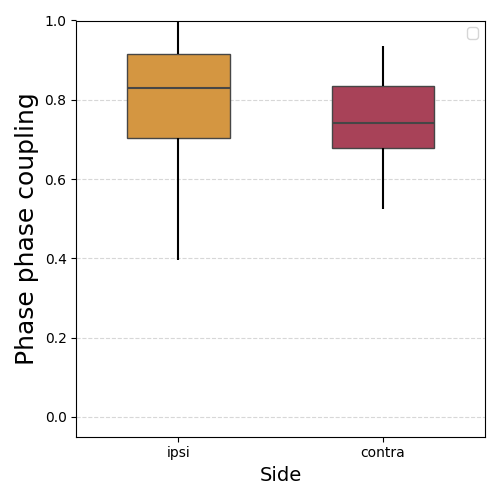

In [4]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

# sns.stripplot(data=df, x="side", y="phase_phase_coupling", hue='side',
#               order=["ipsi", "contra"], palette=my_pal,size=6,alpha=1)

box = sns.boxplot(data=df, x="side", y="phase_phase_coupling", hue='side',
            order=['ipsi','contra'], showfliers=False, showcaps=False,palette=my_pal,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5)  # Using the custom color palette

# ax=sns.violinplot(data=df,x="side", y="phase_phase_coupling", hue='side',
#                 order=["ipsi", "contra"], palette=my_pal,fill=True,inner = None,\
#                 split=True, density_norm='width',saturation=1,bw_adjust=0.5,native_scale=True)
# plt.setp(ax.collections, alpha=.3)

plt.ylabel('Phase phase coupling',fontsize=18)
plt.xlabel('Side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
# plt.legend([], [], frameon=False)
plt.ylim([-0.05,1])
plt.legend()
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()

# os.chdir(figures_path + '/figure_3/')
# fig_name = 'Figure_Ripple_PhasePhaseCoupling_WholeSignal.svg'
# fig_name = 'Figure_Ripple_PhasePhaseCoupling_RippleEvents.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fi_name)



In [5]:
np.sum(df['side'] == 'ipsi')


280

In [6]:
np.sum(df['side'] == 'contra')


320